In [1]:
import polars as pl
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
textos = pl.read_parquet('../database/textos/*.parquet').select('id', 'texto')
metadata = pl.read_parquet('../database/metadata/*.parquet').select('id', 'pubName', 'name', 'artType', 'pubDate', 'artCategory', 'pdfPage')
df = textos.join(metadata, on='id', how='inner')
del textos, metadata

In [3]:
df = df.filter(
    pl.col('artCategory').str.to_lowercase().str.contains(r'(marinha|ex[ée]rcito|aeron[áa]utica)')
).with_columns(
    pl.col('pubDate').str.to_date(format='%d/%m/%Y')
)

# 1. Entendimento do acervo

## Volume de documentos por período

In [4]:
volume_por_ano = df.group_by(pl.col('pubDate').dt.strftime('%Y/%m'), pl.col('pubName').str.head(3)).agg(pl.len()).sort('pubDate', 'pubName')
fig = px.area(volume_por_ano.to_pandas(), x='pubDate', y='len', color='pubName', title='Volume de artigos por mês e publicação')
fig.show()

In [5]:
df = df.filter(pl.col('pubDate').dt.year()>=2018)

## Distribuição por fonte, autor, órgão ou categoria

In [6]:
df.head()

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""515_20190102_11355821""",""" PORTARIA Nº 2.082, DE 27 DE D…","""DO1""","""Port_2082""","""Portaria""",2019-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190102_11355822""",""" PORTARIA Nº 2.083, DE 27 DE D…","""DO1""","""Port_2083""","""Portaria""",2019-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190104_11366759""",""" PORTARIA Nº 401/DPC, DE 19 DE…","""DO1""","""Port-401-2018-DPC-ALTNOR-001-M…","""Portaria""",2019-01-04,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190107_11365668-1""",""" PORTARIA DECEA Nº 258/JJAER,…","""DO1""","""20181210_Portaria_258 JJAER_RJ…","""Portaria""",2019-01-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190107_11365668-2""",""" Art. 38 As sessões serão públ…","""DO1""","""20181210_Portaria_258 JJAER_RJ…","""Portaria""",2019-01-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


In [7]:
distribuicao_por_autor = (
    df
    .filter(
        pl.col('artCategory').str.to_lowercase().str.contains('defesa'),
        pl.col('pubDate').dt.year()>=2018
    )
    .group_by(
        pl.col('artCategory').str.to_uppercase().str.split('/').list.slice(1).alias('Forca'), 
        pl.col('pubName'),
        pl.col('artType').str.to_uppercase()
    )
    .agg(pl.len())
    .sort('len', descending=True)
).with_columns(
    forca=pl.col('Forca').list.first(),
    om=pl.col('Forca').list.last(),
    artType=pl.col('artType').str.replace(r'PORTARIA(S)?', 'PORTARIA'),
    pubName=pl.col('pubName').str.head(3)
).filter((pl.col('forca')!='') & (pl.col('om')!='')).select('forca', 'artType', 'pubName', 'len')

distribuicao_por_autor

forca,artType,pubName,len
str,str,str,u32
"""COMANDO DO EXÉRCITO""","""PORTARIA""","""DO2""",6665
"""COMANDO DA AERONÁUTICA""","""PORTARIA""","""DO2""",6530
"""COMANDO DO EXÉRCITO""","""PORTARIA""","""DO2""",6063
"""COMANDO DA MARINHA""","""PORTARIA""","""DO2""",5542
"""COMANDO DA MARINHA""","""PORTARIA""","""DO2""",4120
…,…,…,…
"""COMANDO DO EXÉRCITO""","""RESULTADO DE JULGAMENTO""","""DO3""",1
"""COMANDO DO EXÉRCITO""","""EXTRATO DE TERMO ADITIVO""","""DO3""",1
"""COMANDO DO EXÉRCITO""","""AVISO DE HOMOLOGAÇÃO""","""DO3""",1


In [8]:
(
    df
    .filter(pl.col('pubDate').dt.year()>=2018)
    .group_by(pl.col('pubDate').dt.year(), pl.col('pubName').str.head(3), 'artType').agg(pl.len()).sort(['pubDate', 'pubName', 'len'], descending=True)
    .show()
)

pubDate,pubName,artType,len
i32,str,str,u32
2026,"""DO3""","""Extrato de Termo Aditivo""",1415
2026,"""DO3""","""Extrato de Contrato""",1075
2026,"""DO3""","""Aviso de Licitação-Pregão""",829
2026,"""DO3""","""Extrato de Credenciamento""",311
2026,"""DO3""","""Extrato de Apostilamento""",180


In [9]:
fig = px.sunburst(distribuicao_por_autor, path=['pubName', 'forca', 'artType'], values='len')
fig.show()

## Tamanho dos textos

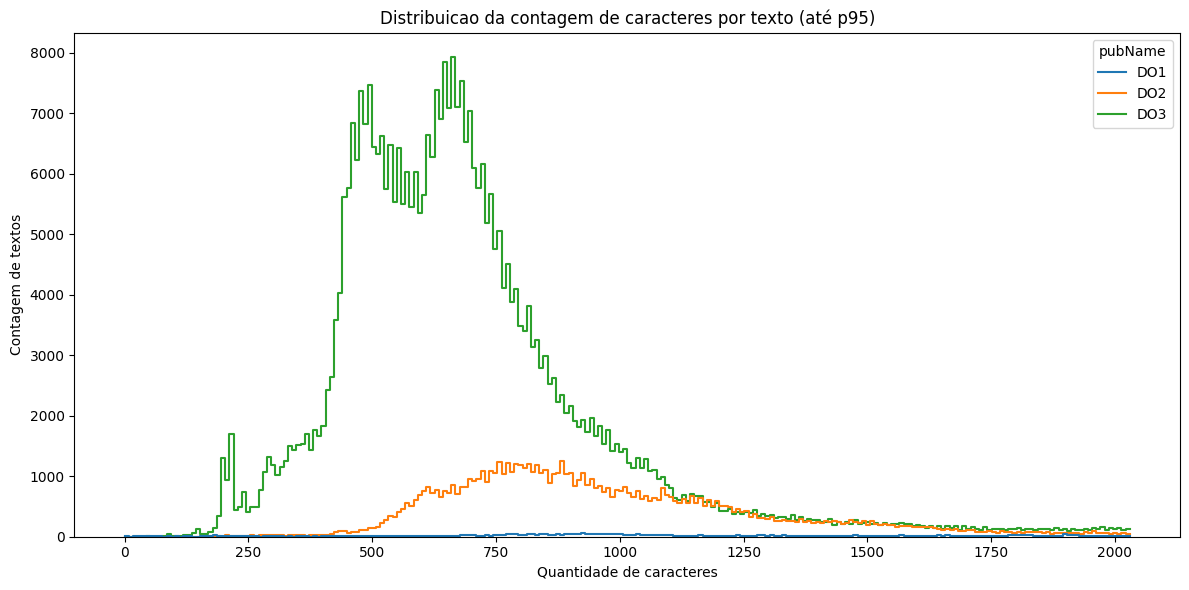

In [10]:
tamanho_por_publicacao = (
    df.select(
        pl.col("pubName").str.head(3).alias("pubName"),
        pl.col("texto").str.len_chars().alias("tamanho")
    )
    .drop_nulls("tamanho")
)

tamanho_pd = tamanho_por_publicacao.to_pandas()

limite_superior = tamanho_pd["tamanho"].quantile(0.95)
plot_data = tamanho_pd[tamanho_pd["tamanho"] <= limite_superior]

plt.figure(figsize=(12, 6))
sns.histplot(
    data=plot_data,
    x="tamanho",
    hue="pubName",
    bins=240,
    stat="count",
    common_norm=False,
    element="step",
    fill=False,
)
plt.title("Distribuicao da contagem de caracteres por texto (até p95)")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Contagem de textos")
plt.tight_layout()
plt.show()


In [11]:
tamanho_por_publicacao.describe()

statistic,pubName,tamanho
str,str,f64
"""count""","""511298""",511298.0
"""null_count""","""0""",0.0
"""mean""",null,1054.020919
"""std""",null,2631.051994
"""min""","""DO1""",0.0
"""25%""",null,547.0
"""50%""",null,696.0
"""75%""",null,915.0
"""max""","""DO3""",243728.0


In [12]:
df.filter(pl.col('texto').str.len_chars() == 0)

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""10695396""","""""","""DO1""","""BALANÇO PATRIMONIAL__170536""","""Balanço Patrimonial""",2018-04-23,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20190426_11640008""","""""","""DO1""","""BALANÇO PATRIMONIAL PDF""","""Balanço Patrimonial""",2019-04-26,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20230524_20621579-13.xml""","""""","""DO1""","""NORMAM-15-REV.3-MOD.3- EM EDIC…","""Portaria""",2023-05-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20240503_21587940-4""","""""","""DO1""","""NPCF CFB_4""","""Norma Complementar""",2024-05-03,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


In [13]:
df.filter(pl.col('texto').str.len_chars() > 1e5).sort(pl.col('texto').str.len_chars(), descending=True).show(limit=-1)

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""515_20210825_13774871-2""","""INTRODUÇÃO 1 -PROPÓSITO Estabe…","""DO1""","""Port-23-2021-DPC-NORMAM-02_2__…","""Portaria""",2021-08-25,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20230919_20957231-9.xml""","""1.31. PETRECHOS PARA ATRAÇÃO E…","""DO1""","""PORT_103_2023_NORMAM-303_9__FG…","""Portaria""",2023-09-19,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20210819_13760714""","""EDITAL Nº 01, DE 09 DE MARÇO D…","""DO3""","""HomologaAAo DOU__BI4YBK""","""Resultado de Concurso Público""",2021-08-19,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20180830_11036998""","""PORTARIA Nº 16-D A PROM, de 22…","""DO2""","""port_promocao_ott_DOU__154231""","""Portaria""",2018-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20190830_11972965""","""PORTARIA Nº 10-D A PROM, DE 26…","""DO2""","""port_promocao_ott_DOU""","""Portaria""",2019-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20220901_19853024""","""PORTARIA-D A PROM/DGP/C Ex nº …","""DO2""","""port_promocao_Of TemporArio pa…","""Portaria""",2022-09-01,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20230427_20549237-1.xml""","""EDITAL DE 26 DE ABRIL DE 2023C…","""DO3""","""Edital - CP-QC-CA-FN-IM 2023_1""","""Edital de Concurso Público""",2023-04-27,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20250120_22312143-2""","""NORMAS DA AUTORIDADE MARÍTIMA …","""DO1""","""PORT-169-2025_NORMAM-101_002""","""Portaria""",2025-01-20,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""515_20210830_13786684-3""","""OBSERVAÇÕES: - Os Oficiais de …","""DO1""","""Port-28-Alt-NORMAM-13_DOU_3""","""Portaria""",2021-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


## Percentagem de textos duplicados ou quase duplicados


In [14]:
df.filter(df.select('texto').is_duplicated())

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""529_20200102_12324586""",""" PORTARIA Nº 2, DE 20 DE DEZE…","""DO2""","""Publicacao DOU nomeacao OD_TCE…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12324586""",""" PORTARIA Nº 2, DE 20 DE DEZE…","""DO2""","""Publicacao DOU nomeacao OD_TCE…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12326901""",""" PORTARIA Nº 1.178-DCIPAS/SPC,…","""DO2""","""PORT-1178-DCIPAS-JOGINALDO-APO…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12326901""",""" PORTARIA Nº 1.178-DCIPAS/SPC,…","""DO2""","""PORT-1178-DCIPAS-JOGINALDO-APO…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""529_20200102_12326902""",""" PORTARIA Nº 1.218-DCIPAS/SPC,…","""DO2""","""PORT-1218-DCIPAS-ANDRÉVIVALDO-…","""Portaria""",2020-01-02,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
…,…,…,…,…,…,…,…
"""530_20251224_23452028""","""EXTRATO DE TERMO ADITIVO Nº 4/…","""DO3""","""2025-12-23/11491399/COMPRASNET…","""Extrato de Termo Aditivo""",2025-12-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20251224_23453175""","""EXTRATO DE TERMO ADITIVO Nº 3/…","""DO3""","""2025-12-23/11492347/COMPRASNET…","""Retificação""",2025-12-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"
"""530_20251226_23456755""","""EXTRATO DE CREDENCIAMENTO Nº 1…","""DO3""","""2025-12-24/11494789/COMPRASNET…","""Extrato de Credenciamento""",2025-12-26,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…"


## Percentual de textos vazios ou muito curtos

In [15]:
df.filter(pl.col('texto').str.len_chars() < 140).show(limit=20, fmt_str_lengths=150)

id,texto,pubName,name,artType,pubDate,artCategory,pdfPage
str,str,str,str,str,date,str,str
"""515_20240126_21349055-2""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=7"""
"""515_20240126_21349055-3""","""Nos anexos: Onde se lê:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-4""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-5""","""Onde se lê:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-6""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=8"""
"""515_20240126_21349055-7""","""Onde se lê:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=9"""
"""515_20240126_21349055-8""","""Leia-se:""","""DO1""","""RETIFICACAO_PORT_115_NORMAM_102_""","""Portaria""",2024-01-26,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=26/01/2024&jornal=515&pagina=9"""
"""515_20250117_22310597-19""","""3.7.16 as bóias classes II e III deverão ser submetidas e aprovada nos seguintes testes:""","""DO1""","""Port-154-2025-DPC NORMAM-321 EDI""","""Portaria""",2025-01-17,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=17/01/2025&jornal=515&pagina=71"""
"""515_20250117_22311209-5""","""1.15. CALADO AÉREO""","""DO1""","""PORT-157-NORMAM-303_005""","""Portaria""",2025-01-17,"""Ministério da Defesa/Comando da Marinha/Diretoria-Geral de Navegação/Diretoria de Portos e Costas""","""http://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=17/01/2025&jornal=515&pagina=124"""


# 2. Qualidade e padronização textual

## Sinônimos com grafias diferentes

## Siglas não padronizadas

## Nomes próprios com múltiplas grafias

## Mudanças históricas de vocabulário

## Boilerplates (cabeçalhos e rodapés)

# 3. Descoberta de temas

## Assuntos dos textos

Pipeline:

Remover números -> remover stopwords -> vetorizar com o tf idf -> tentar reduzir a dimensionalidade com PCA -> clusterizar os documentos pelos vetores obtidos

In [16]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [17]:
all_unumbered_text = df.select(
    pl.col('texto')
    .str.replace_all(r'[\d\.\:\;\,\(\)\/]+', '')
    .str.replace_all('\n', ' ')
    .str.replace_all(r'<\/?p(.*?)>', '')
    .str.strip_chars()
    .str.to_lowercase()
)

In [18]:
all_unumbered_text.group_by(
    pl.col('texto').str.split(' ').list.first()
).agg(pl.len()).sort(by='len', descending=True).show(limit=100)

texto,len
str,u32
"""extrato""",227867
"""aviso""",121723
"""portaria""",92613
"""resultado""",28112
"""edital""",18560
"""retificação""",11082
"""extratos""",2660
"""portarias""",894
"""portaria-dcemdgpc""",576


In [19]:
stop_candidates = {}

for i in range(all_unumbered_text.height):
    print(i, end='\r')
    for word in list(map(lambda x: x.strip(), all_unumbered_text.item(i, 'texto').split(' '))):
        if word not in stop_candidates:
            stop_candidates[word] = 1
        else:
            stop_candidates[word] += 1


In [20]:
stop_candidates

{'portaria': 350683,
 'nº': 1607756,
 '': 8214429,
 'de': 7332802,
 'dezembro': 120008,
 'divulga': 185,
 'o': 1039851,
 'resultado': 62658,
 'das': 464769,
 'metas': 1007,
 'desempenho': 4359,
 'institucional': 6388,
 'do': 1838803,
 'ano': 12923,
 'no': 892669,
 'âmbito': 5940,
 'exército': 102933,
 'para': 561873,
 'fim': 20654,
 'aplicação': 12071,
 'da': 1665846,
 'comandante': 112968,
 'novembro': 45021,
 'uso': 117473,
 'atribuições': 27585,
 'que': 336621,
 'lhe': 89088,
 'conferem': 5068,
 'art': 518357,
 'º': 529547,
 'lei': 336210,
 'complementar': 21367,
 'junho': 61772,
 'alterada': 20658,
 'pela': 131821,
 'agosto': 52233,
 'inciso': 267888,
 'i': 134876,
 'estrutura': 11954,
 'regimental': 7219,
 'comando': 120120,
 'aprovada': 14643,
 'pelo': 168821,
 'decreto': 62987,
 'abril': 54110,
 'em': 528830,
 'conformidade': 17291,
 'com': 406584,
 'março': 87413,
 'e': 1714043,
 'acordo': 127920,
 'as': 144603,
 'avaliações': 1018,
 'realizadas': 3827,
 'pelos': 12122,
 'órgão

In [21]:
stop_candidates = pd.DataFrame({k:[v] for k,v in stop_candidates.items()}).T.reset_index()

In [22]:
len(all_unumbered_text)

511298

In [23]:
(
    pl.DataFrame(stop_candidates)
    .filter(pl.col('index')!='')
    .filter(pl.col('0') < pl.col('0').mean() + 1.5 * (pl.col('0').quantile(0.75) - pl.col('0').quantile(0.25)))
    .sort(by='0', descending=True)
    .show(limit=10)
)

index,0
str,i64
"""quer""",243
"""infláveis""",243
"""içamento""",243
"""avançados""",243
"""""com""",243
"""certificar-se""",243
"""impeçam""",243
"""provisórios""",243
"""bacharelado""",243


In [24]:
tf_idf_matrix = vectorizer.fit_transform(all_unumbered_text.to_series().to_list())

In [25]:
idf_df = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'idf_score': vectorizer.idf_}).sort_values(by='idf_score', ascending=False)

idf_df

,word,idf_score
110660,holloway,13.451563
233139,utlizando,13.451563
117518,inaptidãoincapacidade,13.451563
233133,utipediátrica,13.451563
117516,inaptas,13.451563
...,...,...
185289,processo,1.387241
58810,da,1.300879
70102,do,1.240998
165805,nº,1.052210


In [31]:
tf_idf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34943107 stored elements and shape (511298, 246869)>

In [30]:
pd.DataFrame(tf_idf_matrix, columns=vectorizer.get_feature_names_out())

ValueError: Shape of passed values is (511298, 1), indices imply (511298, 246869)

In [ ]:
atas_do1 = (
    df.filter(
        pl.col('pubName')=='DO1',
        pl.col('artType').str.to_lowercase()=='instrução normativa'
    )
)

for i in range(atas_do1.height):
    print(atas_do1.item(i, 'texto').strip().split('\n'))

Processo xxxxxx
Processo: xxxxx

In [ ]:
(
    df.filter(
        pl.col('pubName')=='DO1'
    )
    .select('artType')
    .unique()
    .sort('artType')
).show(limit=-1)

In [ ]:
portarias_do1

## Temas que dominam o acervo


## Mudança dos temas ao longo do tempo


## Temas exclusivos a certas organizações

# 4. Entidades e relações

## Pessoas

## Organizações


## Localidades


## Cargos


## Valores monetários

## Datas


## Objetos contratuais

## Normas e referências legais

# 5. Evolução temporal

## Variações de frequências de termos

## Eventos que alteram o vocabulário institucional

## Mudança do estilo redacional

## Temas cíclicos


# 6. Padrões de linguagem

## Textos formais ou padronizados


## Verbosidade dos documentos

## Uso de e linguagem técnica administrativa

## Níveis de repetição

## Densidade de termos jurídicos, financeiros ou operacionais

# 7. Anomalias e casos raros

## Documentos com vocabulário muito incomum

## Entidades que aparecem poucas vezes, porém em textos relevantes

## Textos que podem pertencer à classe errada

## Mudanças abruptas de temas em determinados períodos

## Contratos, decisões ou atos com redação única

# 8. Classificação e taxonomia

## Tema principal

## Subtipo documental

## Área funcional

## Natureza do ato

## Tipo de decisão

## Impacto institucional

# 9. Indicadores derivados de texto

## Índice de complexidade textual

## Índice de repetição

## Proporção de termos de contratação, pessoal, norma, logística

## Quantidade de entidades por documento

## Densidade de valores monetários por documento

## Presença de termos chave como urgência, dispensa, nomeação, exoneração, aquisição

# 10. Perguntas do KDD

## Quais são os grandes blocos temáticos do acervo?

## Como esses blocos temáticos tem mudado ao longo dos anos?

## Quais entidades mais aparecem e em quais contextos?

## Existem padrões distintos entre grupos, fontes ou instituições?

## Quais documentos fogem ao padrão esperado?

## Quais termos indicam muidanças de política, prioridade ou atividade?

## Que relações entre entidades são recorrentes?

## Quais temas estão crescendo ou desaparecendo?

## Quais documentos são altamente similares entre si?

## Há sinais de mudanças de linguagem institucional ao longo dos anos?